# Hiero Vision OCR
---
## Project Goal
Deep learning models often achieve excellent OCR performance by learning features automatically. This project explores a different question:

Can carefully engineered features push traditional machine learning approaches to unexpectedly high performance?

Instead of feeding raw images directly into a classical model, a compact spatial representation was designed to preserve structural information while dramatically reducing dimensionality.

The objective was not simply to train another OCR model, but to investigate how far feature engineering alone could push Gradient Boosting based approaches on moderately noisy handwritten data.

Results showed that a handcrafted 64-dimensional representation achieved surprisingly strong performance:

- Gradient Boosting: 99.5%
- Basic ResNet: 99.7%
- Full ResNet: 99.8%

---

### Performance Setup (Recommended)

Before running this notebook, create a RAM-backed filesystem to improve dataset loading and preprocessing speed.

Run the following commands in a terminal:

```bash
mkdir -p ~/ramdisk
sudo mount -t tmpfs -o size=3G tmpfs ~/ramdisk
```
This creates a 3GB RAM disk at:
`~/ramdisk`
---

## Extract MNIST dataset

In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("./data/mnist.zip")
mnist_dir = Path.home() / "ramdisk"
if mnist_dir.exists() is False:
    mnist_dir.mkdir(parents=True, exist_ok=True)
    
if any(mnist_dir.iterdir()) is False:
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(mnist_dir)
mnist_dir.__str__()

## Dataloading
This section prepares the complete data pipeline used throughout training and evaluation.

The dataset is loaded, preprocessing and augmentation steps are configured, and PyTorch dataloaders are created for efficient batch processing. Additional settings such as reproducibility, system configuration, and runtime optimizations are also initialized here.

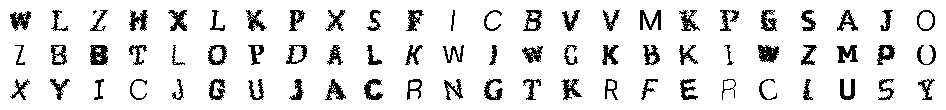

Number of Classes: 26
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Train Dataset Size: 1323680
Test Dataset Size:  153864
-------
NVIDIA GeForce RTX 5070
Batch Size: 2048
Number of Workers: 8
Device: cuda
PyTorch: 2.12.0.dev20260410+cu130
Torch Vission: 0.27.0.dev20260410+cu130


In [11]:
import string
from pyscripts.dataloading import MNIST_Dataset, GetGradientBoostingDecisionTreeData
from torch.utils.data import DataLoader
import torch
import torchvision
from torchvision import transforms
from pyscripts.noise import RealisticNoise
from pyscripts.visualization import ShowRandonPreview, PlotResults, ShowDataPresentation
from tqdm import tqdm
from typing import Tuple, cast

train_dataset_dir = mnist_dir / "train"
test_dataset_dir = mnist_dir / "test"

characters=list(string.ascii_uppercase)
num_classes = len(characters)
batch_size = 2048
workers_count = 8
manual_seed = 42
device = "cuda" if torch.cuda.is_available else "cpu"
dataset_iteration = 8

noise = transforms.Compose(
    [
        transforms.RandomApply([RealisticNoise(prob=0.3)], p=0.6), 
        transforms.RandomApply([RealisticNoise(prob=0.5)], p=0.4), 
    ])

train_dataset = MNIST_Dataset(root_dir=train_dataset_dir, characters=characters, augmentation=noise, iterations=dataset_iteration)
test_dataset = MNIST_Dataset(root_dir=test_dataset_dir, characters=characters, augmentation=noise, iterations=dataset_iteration)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers_count)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True, num_workers=workers_count)

torch.manual_seed(manual_seed)
ShowRandonPreview(dataloader=train_loader, rows=3, columns=24)

print(f"Number of Classes: {num_classes}")
print(f"Classes: {characters}")
print(f"Train Dataset Size: {train_dataset.__len__()}") 
print(f"Test Dataset Size:  {test_dataset.__len__()}")
print("-------")
print(torch.cuda.get_device_name(0))
print(f"Batch Size: {batch_size}")
print(f"Number of Workers: {workers_count}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Torch Vission: {torchvision.__version__}")


## Feature Engineering Strategy

Rather than directly flattening images into hundreds of raw pixel values, a compact representation was intentionally designed to preserve structural information while reducing dimensionality.

The objective was to encode local and global image characteristics into a form more suitable for traditional machine learning algorithms.

This representation captures information at multiple scales, allowing Gradient Boosting models to reason about shape, density, and spatial distribution instead of memorizing individual pixels.

## Data Presentation

The original input images have a resolution of **21×21 pixels**, producing 441 raw pixel values.

Instead of feeding raw pixels directly into a classical machine learning model, each image is transformed into a compact **64-dimensional feature vector**.

Feature layout:

- First 49 values: local 3×3 regions
- Next 9 values: larger 7×7 regions
- Next 3 values: horizontal stripe summaries
- Final 3 values: vertical stripe summaries

Each feature value represents the number of dark pixels contained inside its corresponding region.

This representation preserves spatial structure while reducing dimensionality from **441 → 64**, making it more suitable for Gradient Boosting based models.

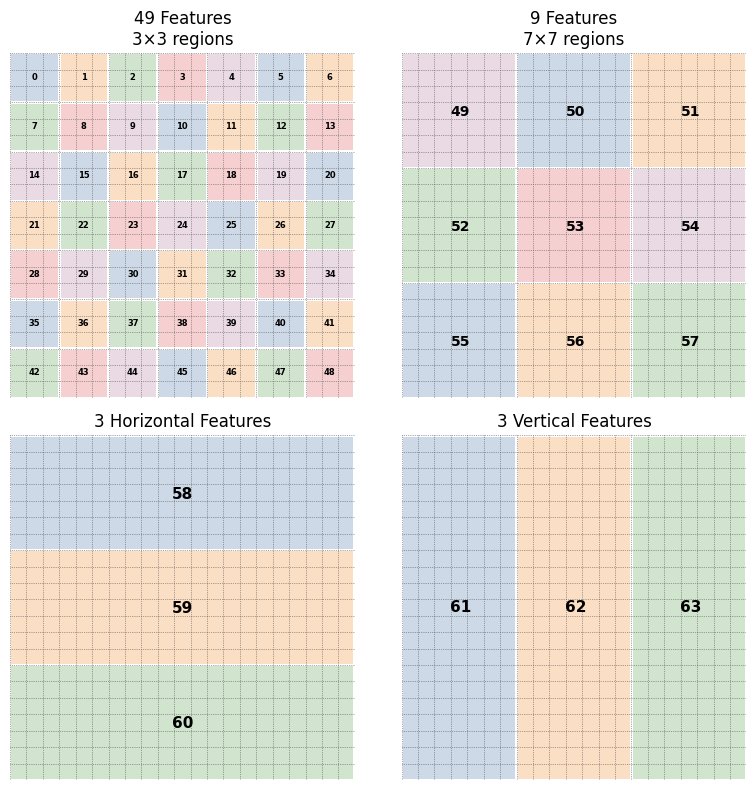

In [12]:
ShowDataPresentation()

## Why Not Raw Pixels?

A 21×21 image contains 441 independent pixel values. Feeding all raw values directly into classical machine learning models increases dimensionality and introduces unnecessary noise.

Instead of learning from individual pixels, the model receives compact spatial summaries extracted at multiple scales.

This reduces dimensionality from 441 values to only 64 engineered features while preserving meaningful structural patterns.

## Gradient Boosting Data Preparation

Unlike deep learning models, Gradient Boosting algorithms cannot directly process image tensors. The dataset must first be converted into a structured numerical representation.

This section extracts image features and transforms the training and testing datasets into a format suitable for Gradient Boosting based models.

After this step, the generated data can be used for training traditional machine learning approaches such as Gradient Boosting Decision Trees.

In [13]:
X_train, y_train = GetGradientBoostingDecisionTreeData(train_loader, title="training")
X_test, y_test = GetGradientBoostingDecisionTreeData(test_loader, title="testing")
len(X_train), len(X_test)

(1323680, 153864)

## Classical Machine Learning Pipeline

At this stage the transformed feature vectors are ready for training.

Unlike convolutional neural networks, Gradient Boosting models do not learn spatial hierarchies automatically. Their performance depends heavily on the quality of feature representation.

The following training stage evaluates how far carefully engineered features can push a traditional machine learning approach.

---

### Light Gradient Boosting Machine

A gradient boosting implementation optimized for speed and efficiency, used to evaluate how well engineered features perform with tree-based learning.

Best Iteration: 986
Train Accuracy: 99.9992445304001
Test Accuracy : 99.57884885353299
Train LogLoss: 0.0002671944901802737
Test LogLoss : 0.012710086886196478


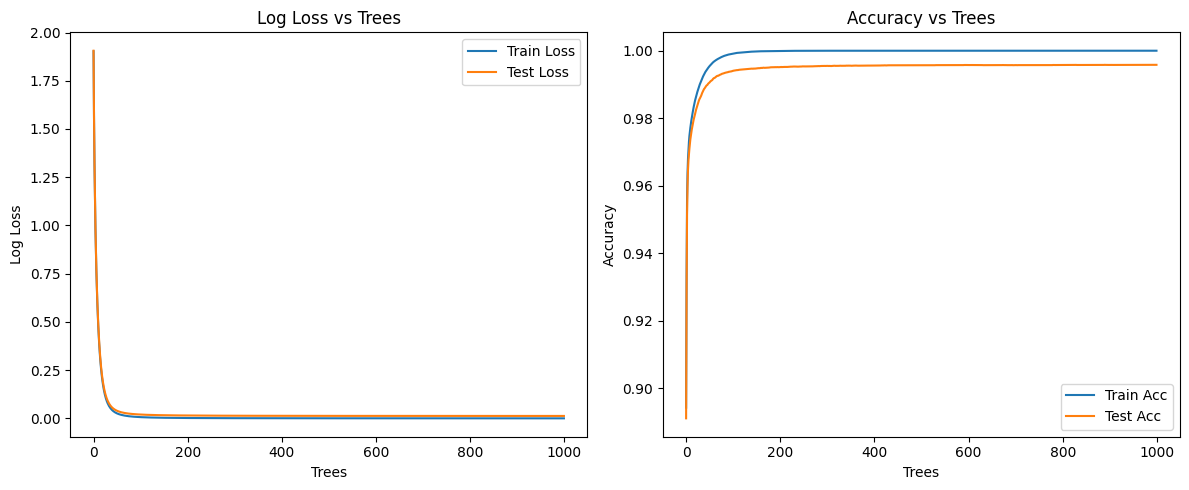

In [15]:
from lightgbm import LGBMClassifier
lr = 0.07
epochs=1000

progress_bar = tqdm(total=epochs, ncols=100, bar_format="{bar}| {n_fmt}/{total_fmt} {postfix}", ascii="|█", position=0, leave=False)

def tqdm_callback(env):
    progress_bar.update(1)
    for data_name, metric_name, value, _ in env.evaluation_result_list:
        if data_name == "valid_1" and metric_name == "multi_error":
            test_acc = 1 - value
            progress_bar.set_postfix({"Accuracy": f"{test_acc:.4f}"})

classifier = LGBMClassifier(
    objective="multiclass", learning_rate=lr, n_estimators=epochs, max_depth=-1, num_class=26, verbose=-1,
    num_leaves=256, min_data_in_leaf=50, feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=2, lambda_l2=15)

classifier.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], eval_metric=["multi_logloss", "multi_error"], callbacks=[tqdm_callback])

progress_bar.close()

results = classifier.evals_result_
train_loss = results["training"]["multi_logloss"]
test_loss  = results["valid_1"]["multi_logloss"]
train_acc = [1 - x for x in results["training"]["multi_error"]]
test_acc  = [1 - x for x in results["valid_1"]["multi_error"]]

PlotResults(train_loss=train_loss, test_loss=test_loss, train_acc=train_acc, test_acc=test_acc)

### XGBoost

A high-performance gradient boosting framework designed to improve predictive accuracy through sequential tree refinement.

Best Iteration: 1991
Train Accuracy: 99.99901788952013
Test Accuracy : 99.59704674257786
Train LogLoss: 0.00067904403507152
Test LogLoss : 0.01184218067170436


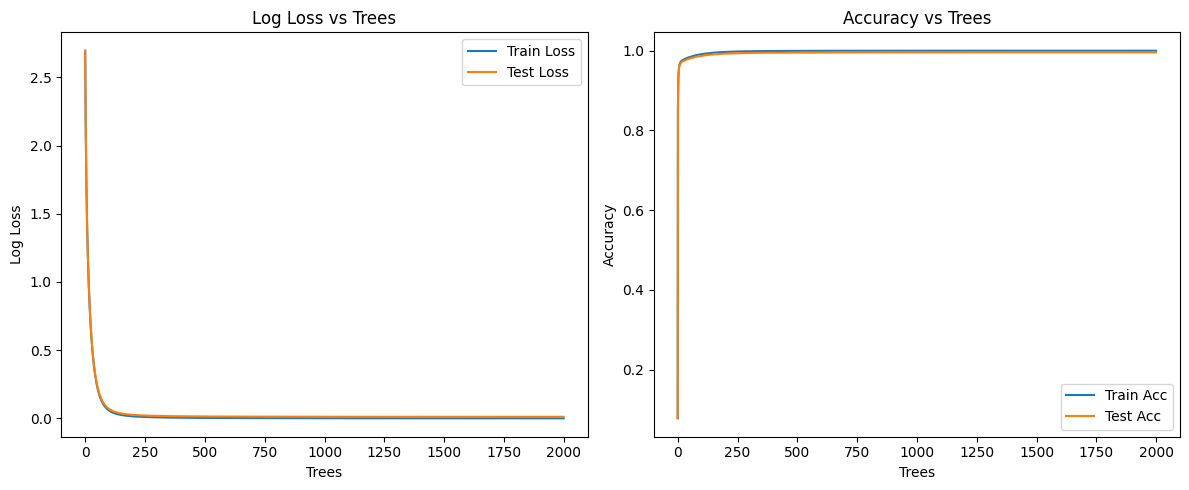

In [16]:
from xgboost import XGBClassifier
from xgboost.callback import TrainingCallback

lr = 0.05
epochs=2000

progress_bar = tqdm(total=epochs, ncols=100,bar_format="{bar} {n_fmt}/{total_fmt} {postfix}", ascii="|█", position=0, leave=False)

class TqdmCallback(TrainingCallback):
    def after_iteration(self, model, epoch, evals_log):
        progress_bar.update(1)
        val_error = cast(float, evals_log["validation_1"]["merror"][-1])
        progress_bar.set_postfix({"Accuracy": f"{1 - val_error:.4f}"})
        return False

classifier = XGBClassifier(
    objective="multi:softprob", n_jobs=-1, eval_metric=["mlogloss", "merror"], 
    num_class=26, n_estimators=epochs, learning_rate=lr, 
    max_depth=8,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=15,
    tree_method="hist",  
    device=device, callbacks=[TqdmCallback()])

classifier.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

progress_bar.close()
results = classifier.evals_result()
train_loss = results["validation_0"]["mlogloss"]
test_loss  = results["validation_1"]["mlogloss"]
train_acc = [1 - x for x in results["validation_0"]["merror"]]
test_acc  = [1 - x for x in results["validation_1"]["merror"]]

PlotResults(train_loss=train_loss, test_loss=test_loss, train_acc=train_acc, test_acc=test_acc)

### CatBoost

A gradient boosting approach focused on strong generalization and robust training behavior across diverse feature representations.

Best Iteration: 7998
Train Accuracy: 99.9796778677626
Test Accuracy : 99.57689907970675
Train LogLoss: 0.0025379628638294376
Test LogLoss : 0.012330355872566439


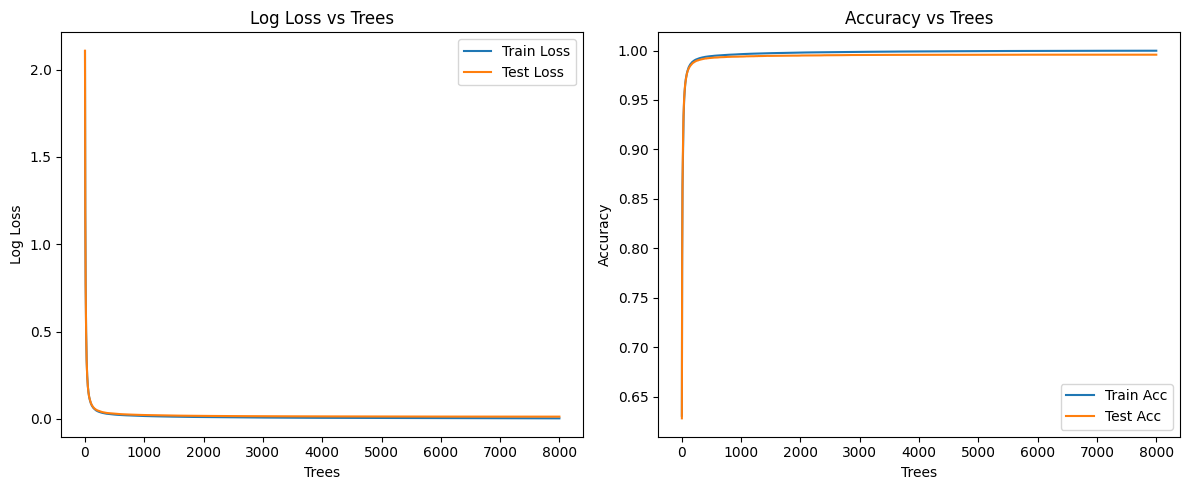

In [21]:
from catboost import CatBoostClassifier
import numpy as np
from typing import cast

lr = 0.11
epochs=8000
progress_bar = tqdm(total=epochs, ncols=100, bar_format="{bar} {n_fmt}/{total_fmt} {postfix}", ascii="|█", position=0, leave=False)

class TqdmWriter:
    def write(self, msg): 
        try:
            progress_bar.n = int(cast(str, msg).split(':')[0])
            progress_bar.refresh()
        except: pass

cassifier = CatBoostClassifier(
    iterations=epochs, learning_rate=lr, verbose=1, task_type="GPU", devices="0", loss_function="MultiClass", eval_metric="MultiClass", custom_metric=["Accuracy"],
    depth=7, l2_leaf_reg=15, random_strength=1, bagging_temperature=1)

cassifier.fit(X_train, y_train, eval_set=(X_test, y_test), log_cout=TqdmWriter())
progress_bar.close()

results = cassifier.get_evals_result()
train_loss = results["learn"]["MultiClass"]
test_loss  = results["validation"]["MultiClass"]
train_acc  = results["learn"]["Accuracy"]
test_acc   = results["validation"]["Accuracy"]

PlotResults(train_loss=train_loss, test_loss=test_loss, train_acc=train_acc, test_acc=test_acc)

### Mini ResNet

A lightweight residual architecture used to compare feature-engineered classical methods against learned convolutional representations.

Best Iteration: 53
Train Accuracy: 99.80735525202465
Test Accuracy : 99.80762231581136
Train LogLoss: 0.0059340531985959555
Test LogLoss : 0.006177371413759679


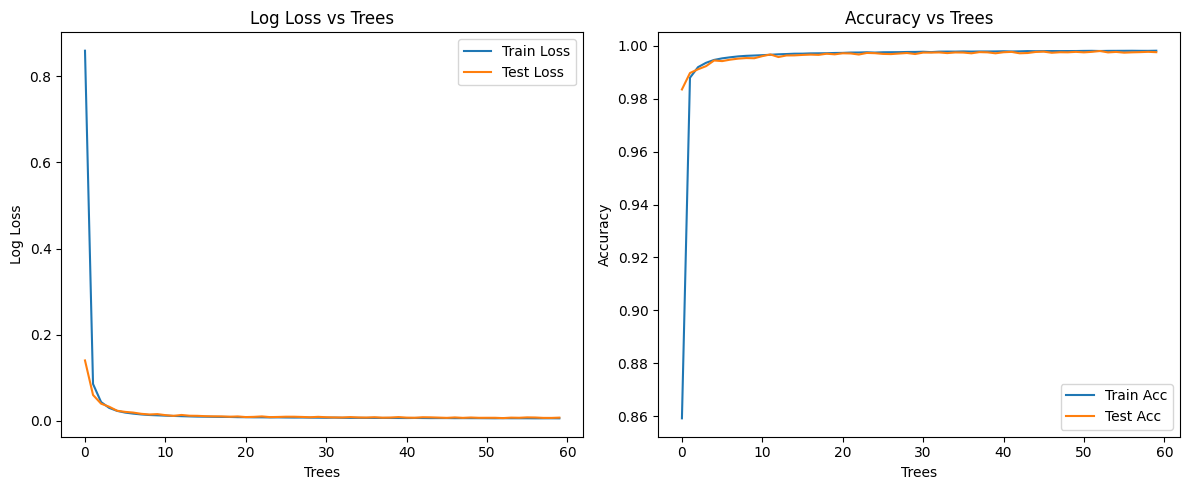

In [18]:
from pyscripts.models import MiniNet
from torch import nn
from pyscripts.trainer import TrainModel

lr = 0.001
epochs = 60
resnet_model = MiniNet().to(device)

TrainModel(model=resnet_model, train_loader=train_loader, test_loader=test_loader, learning_rate=lr, epochs=epochs, device=device )

### WideResNet

A deeper residual architecture intended to maximize learned representation capacity and establish an upper performance bound.

Best Iteration: 53
Train Accuracy: 99.91931584673033
Test Accuracy : 99.89406228877449
Train LogLoss: 0.0024035806827081433
Test LogLoss : 0.003114878186097118


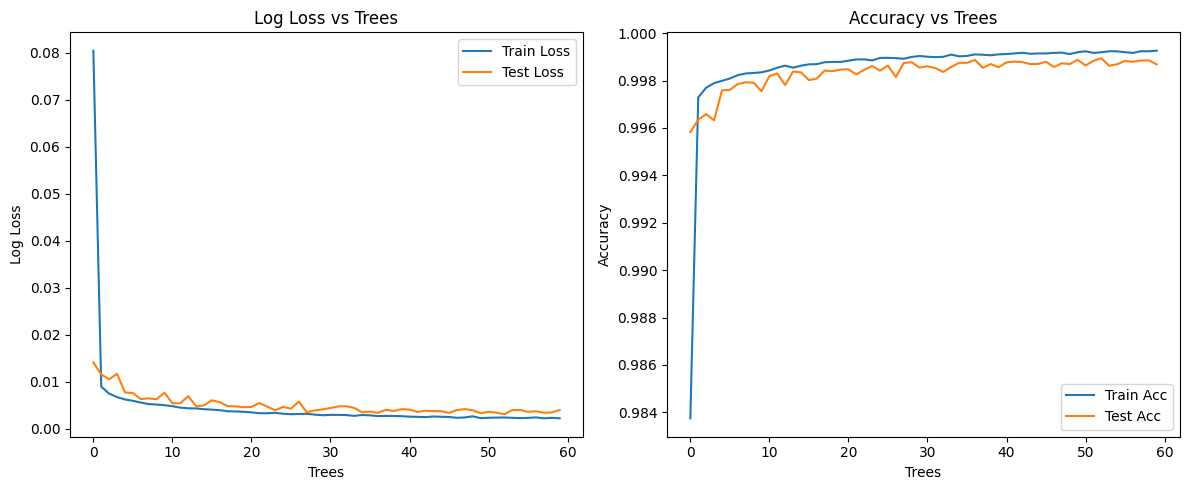

In [19]:
from pyscripts.models import WideResNet21
from torch import nn
from pyscripts.trainer import TrainModel

lr = 0.001
epochs = 60
resnet_model = WideResNet21(num_classes=26).to(device)
TrainModel(model=resnet_model, train_loader=train_loader, test_loader=test_loader, learning_rate=lr, epochs=epochs, device=device )

| Model | Accuracy |
|--------|-----------|
| LightGBM | 99.57% |
| XGBoost | 99.59% |
| CatBoost | 99.56% |
| Mini ResNet | 99.80% |
| WideResNet21 | 99.89% |

## Key Observation

The most interesting result was not achieving as high as deep learning accuracy.

The surprising result was how closely a handcrafted feature representation allowed a classical machine learning model to approach deep residual architectures.

This suggests that carefully designed feature engineering can remain highly competitive even in domains frequently dominated by deep learning.

## Conclusions

Feature engineering significantly reduced dimensionality while preserving meaningful spatial information.

The most surprising result was not achieving strong deep learning performance, but demonstrating how closely a carefully engineered classical pipeline could approach residual architectures.

Classical Gradient Boosting based models achieved competitive performance while operating at substantially lower computational cost. Training and inference remained significantly faster than deep residual networks while requiring only a small reduction in final accuracy.

Most notably, the engineered representation compressed each sample from 441 raw pixel values to only 64 carefully designed features while still achieving 99.4% accuracy on moderately noisy data.

This project highlights that carefully designed representations can provide an attractive tradeoff between performance, speed, and model complexity.

## Related Project

This work was supported by a companion project:

**MNIST Builder for PyTorch**

A custom WPF application used to generate MNIST-style datasets directly from Google Fonts and export them in a PyTorch-compatible structure.

Repository:

https://github.com/mgoyalitm/mnist-builder-for-pytorch

## Connect

Additional work and professional profiles:

GitHub: https://github.com/mgoyalitm

LinkedIn: https://www.linkedin.com/in/mgoyal-itm

Toptal: https://www.toptal.com/developers/resume/mahendra-goyal